In [14]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, logomaker
from pathlib import Path

FG_ROOT = Path('/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq/foregrounds')
SIT     = Path('/grid/koo/home/pmantill/projects/situate')

# SEAM_val annotations: situate/edits.csv rows keyed
# "SEAM:K562:{peak}:foreground_scaled", already in var-region coords [0,200).
_raw  = pd.read_csv(SIT / 'edits.csv')
_seam = _raw[_raw.sequence_name.str.startswith('SEAM:K562:', na=False)
             & _raw.sequence_name.str.endswith(':foreground_scaled', na=False)].copy()
_seam['peak'] = _seam.sequence_name.str.split(':').str[2]
ann = _seam.assign(sequence_name=_seam['peak'])   # cell 3 / KO cells filter by peak name
PEAK_TO_ANNROW = {p: p for p in ann['peak'].unique()}
PEAK_TO_ANNROW

{'ENSG00000143384': 'ENSG00000143384',
 'peak10288_Reversed': 'peak10288_Reversed',
 'peak20130': 'peak20130',
 'peak26256': 'peak26256',
 'peak27535_Reversed': 'peak27535_Reversed',
 'peak38192_Reversed': 'peak38192_Reversed',
 'peak49966_Reversed': 'peak49966_Reversed',
 'peak84030': 'peak84030'}

In [15]:
# auto-detect finished foregrounds: dir must contain the final foreground_scaled.npy
finished = sorted(d.name for d in FG_ROOT.iterdir()
                  if d.is_dir() and (d / 'foreground_scaled.npy').exists())
print(f'{len(finished)} finished foreground(s):')
for p in finished:
    has = 'annotated' if p in PEAK_TO_ANNROW else 'NO annotations'
    print(f'  {p:24s} {has}')

8 finished foreground(s):
  ENSG00000143384          annotated
  peak10288_Reversed       annotated
  peak20130                annotated
  peak26256                annotated
  peak27535_Reversed       annotated
  peak38192_Reversed       annotated
  peak49966_Reversed       annotated
  peak84030                annotated


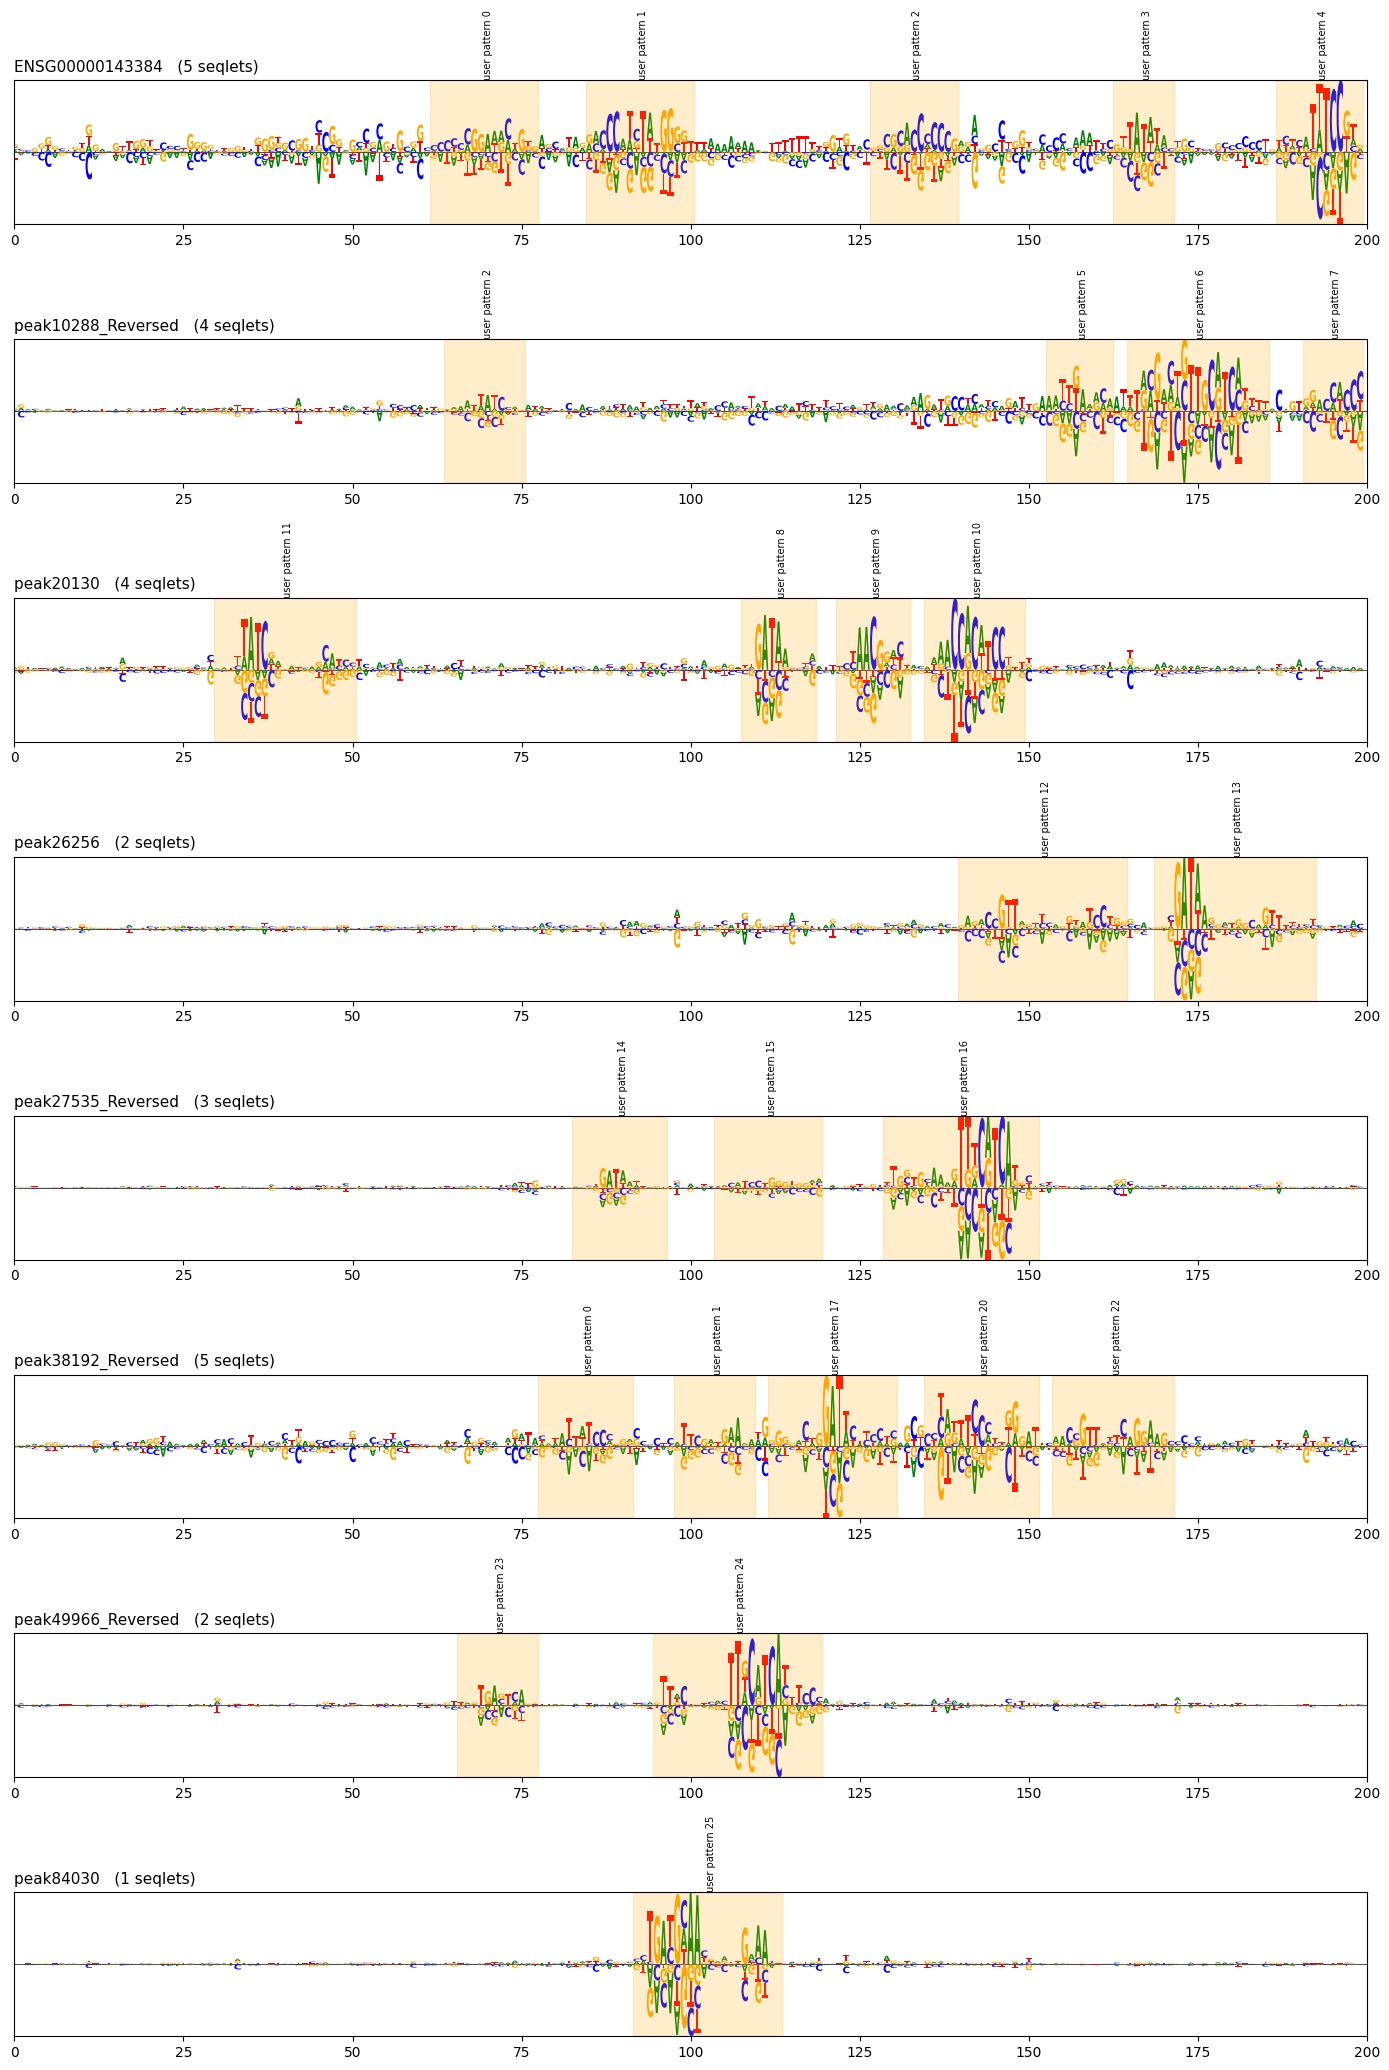

In [16]:
# one foreground logo per finished seq, annotated seqlets overlaid as labelled spans
fig, axes = plt.subplots(len(finished), 1, figsize=(14, 2.6 * len(finished)), squeeze=False)
for ax, peak in zip(axes[:, 0], finished):
    fg = np.load(FG_ROOT / peak / 'foreground_scaled.npy')          # (200, 4)
    logomaker.Logo(pd.DataFrame(fg, columns=list('ACGT')), ax=ax)   # raw 4-channel logo

    row = PEAK_TO_ANNROW.get(peak)
    seqlets = ann[ann.sequence_name == row] if row is not None else ann.iloc[0:0]
    for _, m in seqlets.iterrows():
        ax.axvspan(m.start - 0.5, m.end - 0.5, color='orange', alpha=0.2)
        ax.text((m.start + m.end) / 2, ax.get_ylim()[1], m.motif_name,
                ha='center', va='bottom', fontsize=7, rotation=90)

    tag = f'{len(seqlets)} seqlets' if row is not None else 'no annotations yet'
    ax.set_title(f'{peak}   ({tag})', loc='left', fontsize=11)
    ax.set_yticks([])
    ax.set_xlim(0, 200)
fig.tight_layout()

## KO predictions: motif-syntax vs context vs full KO

Three perturbations per seq, all drawn from the **same 30** variable-region dinuc-shuffles
(constant adapter flanks always kept WT):

- **motif KO** — annotated motifs shuffled, rest of the sequence kept → *motif-syntax box*
- **context KO** — variable-region context shuffled, annotated motifs kept → *context box*
- **full KO** — entire variable region shuffled, nothing kept → *full-shuffle box*

The plot shows **Δ = KO − WT** prediction per replicate (dashed line at 0 = no change;
negative = the knocked-out element was activating). Needs a GPU node (loads the K562 pred_koo encoder).

In [17]:
import sys
# force the SEAM/Hippo build of the encoder (matches the K562 ckpt's HeadConfig)
sys.path.insert(0, '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/'
                   'Hippo_dependency_chromatin-accessibility/alphagenome-encoder-ft/src')
import h5py, torch
from tangermeme.utils import one_hot_encode
from tangermeme.ersatz import dinucleotide_shuffle
from alphagenome_encoder_ft import EncoderMPRAModel

LIB   = Path('/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq/mutagenesis_lib')
N_REP = 30

CKPT = '/grid/koo/home/shared/models/alphagenome_encoder/torch/mpra_K562/finetuned_encoder.pt'
model = EncoderMPRAModel.from_checkpoint(CKPT, device='cuda').eval()
cfg = torch.load(CKPT, map_location='cpu', weights_only=False)['construct_config']
suffix = one_hot_encode(cfg['promoter_seq'] + cfg['barcode_seq']).float()  # (4,51) promoter+barcode

@torch.no_grad()
def predict_k562(insert_ohe):                       # (B,4,230) -> (B,) K562 pred
    x = torch.cat([insert_ohe, suffix.expand(len(insert_ohe), -1, -1)], 2)  # (B,4,281)
    return model(x.transpose(1, 2).cuda()).cpu().numpy()

ko_peaks = [p for p in finished if p in PEAK_TO_ANNROW]   # only seqs we have motif annotations for
print('context-KO on:', ko_peaks)

context-KO on: ['ENSG00000143384', 'peak10288_Reversed', 'peak20130', 'peak26256', 'peak27535_Reversed', 'peak38192_Reversed', 'peak49966_Reversed', 'peak84030']


In [18]:
# three KO conditions from the SAME 30 var-region shuffles; adapters always stay WT:
#   context KO -> variable-region context shuffled, annotated motifs kept  (context box)
#   motif KO   -> annotated motifs shuffled, rest of the sequence kept     (motif-syntax box)
#   full KO    -> entire variable region shuffled, nothing kept            (full-shuffle box)
wt_pred, ctxko_pred, motifko_pred, fullko_pred = {}, {}, {}, {}
for peak in ko_peaks:
    with h5py.File(LIB / f'{peak}.h5') as f:
        wt_str  = f.attrs['wt_seq_str']
        ADAPTER = int(f.attrs['var_start'])          # variable region = insert[ADAPTER : ADAPTER+200]
    wt     = one_hot_encode(wt_str).float()                                          # (4,230)
    var    = slice(ADAPTER, ADAPTER + 200)
    shuf   = dinucleotide_shuffle(wt[:, var].unsqueeze(0), n=N_REP, random_state=0)[0]  # (30,4,200) var-region shuffles
    motifs = ann[ann.sequence_name == PEAK_TO_ANNROW[peak]]

    # full KO: replace the whole variable region with the shuffle, keep nothing
    full = wt.unsqueeze(0).repeat(N_REP, 1, 1).clone()
    full[:, :, var] = shuf

    # context KO: full-shuffle variable region, then paste motifs back
    ctx = full.clone()
    for _, m in motifs.iterrows():
        ctx[:, :, m.start + ADAPTER : m.end + ADAPTER] = wt[:, m.start + ADAPTER : m.end + ADAPTER]

    # motif KO: keep WT everywhere, replace only the motif positions with the shuffle (shuf is var-indexed)
    mot = wt.unsqueeze(0).repeat(N_REP, 1, 1).clone()
    for _, m in motifs.iterrows():
        mot[:, :, m.start + ADAPTER : m.end + ADAPTER] = shuf[:, :, m.start : m.end]

    wt_pred[peak]      = float(predict_k562(wt.unsqueeze(0))[0])
    fullko_pred[peak]  = predict_k562(full)    # (30,) one per replicate
    ctxko_pred[peak]   = predict_k562(ctx)     # (30,)
    motifko_pred[peak] = predict_k562(mot)     # (30,)
    print(f'{peak:24s} WT={wt_pred[peak]:+.3f}   ctxKO={ctxko_pred[peak].mean():+.3f}   '
          f'motifKO={motifko_pred[peak].mean():+.3f}   fullKO={fullko_pred[peak].mean():+.3f}')

ENSG00000143384          WT=+1.414   ctxKO=+1.046   motifKO=-0.196   fullKO=-0.425
peak10288_Reversed       WT=+1.640   ctxKO=+0.926   motifKO=-0.432   fullKO=-0.425
peak20130                WT=+1.358   ctxKO=+0.602   motifKO=-0.271   fullKO=-0.344
peak26256                WT=+1.732   ctxKO=+1.127   motifKO=-0.448   fullKO=-0.426
peak27535_Reversed       WT=+1.765   ctxKO=+0.458   motifKO=-0.543   fullKO=-0.504
peak38192_Reversed       WT=+1.402   ctxKO=+0.840   motifKO=-0.267   fullKO=-0.299
peak49966_Reversed       WT=+1.582   ctxKO=+1.296   motifKO=-0.430   fullKO=-0.437
peak84030                WT=+1.795   ctxKO=+0.778   motifKO=-0.029   fullKO=-0.405


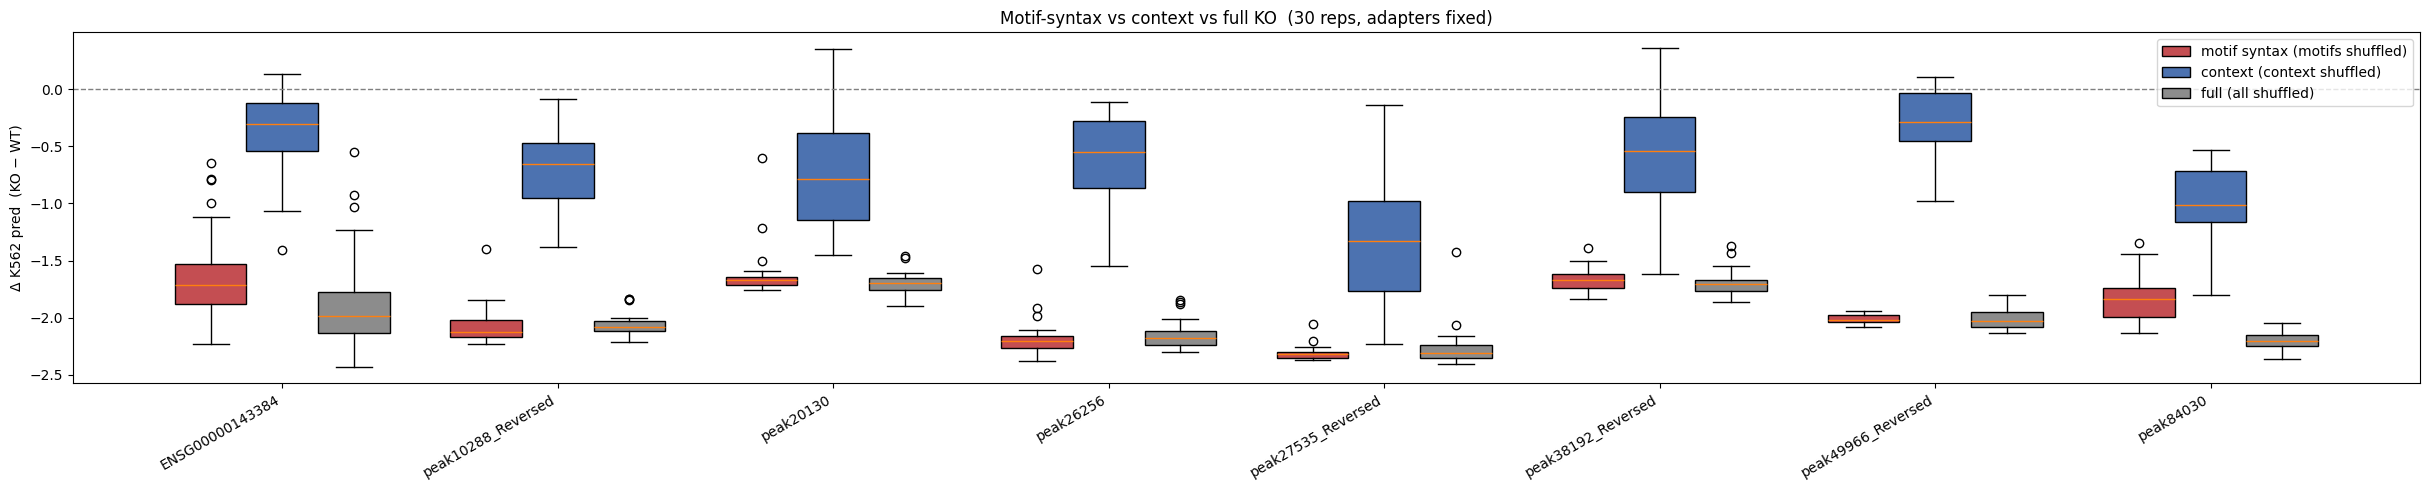

In [19]:
# delta = KO - WT prediction (per replicate); three boxes per seq: motif-syntax / context / full KO
w = 0.26
xg = np.arange(len(ko_peaks))
d_mot  = [motifko_pred[p] - wt_pred[p] for p in ko_peaks]   # motif-syntax box: motifs shuffled, context kept
d_ctx  = [ctxko_pred[p]   - wt_pred[p] for p in ko_peaks]   # context box: context shuffled, motifs kept
d_full = [fullko_pred[p]  - wt_pred[p] for p in ko_peaks]   # full-shuffle box: whole var region shuffled

fig, ax = plt.subplots(figsize=(2.8 * len(ko_peaks) + 2, 5))
b_mot  = ax.boxplot(d_mot,  positions=xg - w, widths=w, patch_artist=True)
b_ctx  = ax.boxplot(d_ctx,  positions=xg,     widths=w, patch_artist=True)
b_full = ax.boxplot(d_full, positions=xg + w, widths=w, patch_artist=True)
for b in b_mot['boxes']:  b.set_facecolor('#c44e52')
for b in b_ctx['boxes']:  b.set_facecolor('#4c72b0')
for b in b_full['boxes']: b.set_facecolor('#8c8c8c')
ax.axhline(0, color='0.5', lw=1, ls='--')
ax.set_xticks(xg); ax.set_xticklabels(ko_peaks, rotation=30, ha='right')
ax.set_ylabel('Δ K562 pred  (KO − WT)')
ax.set_title(f'Motif-syntax vs context vs full KO  ({N_REP} reps, adapters fixed)')
ax.legend([b_mot['boxes'][0], b_ctx['boxes'][0], b_full['boxes'][0]],
          ['motif syntax (motifs shuffled)', 'context (context shuffled)', 'full (all shuffled)'])
fig.tight_layout()

In [20]:
# Rescue the context KO by restoring one dinucleotide class's WT positions, two ways.
# Each class pairs a dinuc with its complement strand (per Pablo): CpG=CG/GC, AT=AT/TA, AA=AA/TT.
#   A "knock-in"   : full-region shuffle (same as ctxKO) + motifs pasted back + WT dinucs knocked in
#                    -> dinuc positions restored, but dinuc content altered (extra copies added).
#   B "dinuc-kept" : pin the dinucs, dinuc-shuffle only the stretches between, paste motifs back
#                    -> dinuc positions restored AND total dinuc content preserved exactly.
CATS = {'CpG': ('CG', 'GC'), 'AT': ('AT', 'TA'), 'AA': ('AA', 'TT')}

def _load(peak):
    with h5py.File(LIB / f'{peak}.h5') as f:
        wt_str  = f.attrs['wt_seq_str']; ADAPTER = int(f.attrs['var_start'])
    wt     = one_hot_encode(wt_str).float()
    vseq   = wt_str[ADAPTER:ADAPTER + 200].upper()
    motifs = ann[ann.sequence_name == PEAK_TO_ANNROW[peak]]
    shuf   = dinucleotide_shuffle(wt[:, ADAPTER:ADAPTER + 200].unsqueeze(0), n=N_REP, random_state=0)[0]
    return wt, vseq, motifs, ADAPTER, shuf

def _paste_motifs(x, wt, motifs, ADAPTER):
    for _, m in motifs.iterrows():
        x[:, :, m.start + ADAPTER : m.end + ADAPTER] = wt[:, m.start + ADAPTER : m.end + ADAPTER]

def rescue_A(peak, dinucs):                                  # knock-in
    wt, vseq, motifs, ADAPTER, shuf = _load(peak)
    x = wt.unsqueeze(0).repeat(N_REP, 1, 1).clone()
    x[:, :, ADAPTER:ADAPTER + 200] = shuf
    _paste_motifs(x, wt, motifs, ADAPTER)
    for i in range(199):
        if vseq[i:i+2] in dinucs:
            x[:, :, i + ADAPTER : i + ADAPTER + 2] = wt[:, i + ADAPTER : i + ADAPTER + 2]
    return predict_k562(x)

def rescue_B(peak, dinucs):                                  # dinuc-preserving (shuffle around pinned dinucs)
    wt, vseq, motifs, ADAPTER, _ = _load(peak)
    pinned = np.zeros(200, bool)
    for i in range(199):
        if vseq[i:i+2] in dinucs:
            pinned[i:i+2] = True
    segs, i = [], 0
    while i < 200:
        if pinned[i]:
            i += 1; continue
        j = i
        while j < 200 and not pinned[j]:
            j += 1
        segs.append((i, j)); i = j
    x = wt.unsqueeze(0).repeat(N_REP, 1, 1).clone()
    for a, b in segs:
        if b - a < 3:
            continue
        seg = one_hot_encode(vseq[a:b]).float().unsqueeze(0)
        try:
            sh = dinucleotide_shuffle(seg, n=N_REP, random_state=0)[0]
        except (ValueError, RuntimeError):
            continue
        x[:, :, a + ADAPTER : b + ADAPTER] = sh
    _paste_motifs(x, wt, motifs, ADAPTER)
    return predict_k562(x)

rescueA = {c: {p: rescue_A(p, d) for p in ko_peaks} for c, d in CATS.items()}   # knock-in
rescueB = {c: {p: rescue_B(p, d) for p in ko_peaks} for c, d in CATS.items()}   # dinuc-preserving
for c in CATS:
    for p in ko_peaks:
        print(f'{p:22s} {c:3s}  ctxKO={ctxko_pred[p].mean():+.3f}  '
              f'A(knock-in)={rescueA[c][p].mean():+.3f}  B(dinuc-kept)={rescueB[c][p].mean():+.3f}')

ENSG00000143384        CpG  ctxKO=+1.046  A(knock-in)=+1.098  B(dinuc-kept)=+1.198
peak10288_Reversed     CpG  ctxKO=+0.926  A(knock-in)=+0.919  B(dinuc-kept)=+1.358
peak20130              CpG  ctxKO=+0.602  A(knock-in)=+0.709  B(dinuc-kept)=+0.933
peak26256              CpG  ctxKO=+1.127  A(knock-in)=+1.184  B(dinuc-kept)=+1.586
peak27535_Reversed     CpG  ctxKO=+0.458  A(knock-in)=+0.759  B(dinuc-kept)=+1.055
peak38192_Reversed     CpG  ctxKO=+0.840  A(knock-in)=+0.991  B(dinuc-kept)=+1.296
peak49966_Reversed     CpG  ctxKO=+1.296  A(knock-in)=+1.329  B(dinuc-kept)=+1.438
peak84030              CpG  ctxKO=+0.778  A(knock-in)=+1.034  B(dinuc-kept)=+1.476
ENSG00000143384        AT   ctxKO=+1.046  A(knock-in)=+1.056  B(dinuc-kept)=+1.095
peak10288_Reversed     AT   ctxKO=+0.926  A(knock-in)=+0.661  B(dinuc-kept)=+1.289
peak20130              AT   ctxKO=+0.602  A(knock-in)=+0.467  B(dinuc-kept)=+0.967
peak26256              AT   ctxKO=+1.127  A(knock-in)=+1.211  B(dinuc-kept)=+1.482
peak

In [21]:
# control rescue: take the CONTEXT KO background (context shuffled, motifs kept = ctxko) and knock
# a 10-bp poly-A tract into it at a RANDOM position (different per rep), avoiding the motifs.
# Tests whether any arbitrary inserted element rescues the context KO. NOT the full-KO background.
TRACT_LEN = 13
TRACT = one_hot_encode('A' * TRACT_LEN).float()  # (4,10)
polyA_pred = {}
rng = np.random.default_rng(0)
for peak in ko_peaks:
    wt, vseq, motifs, ADAPTER, shuf = _load(peak)

    ctx = wt.unsqueeze(0).repeat(N_REP, 1, 1).clone()    # build the context KO background:
    ctx[:, :, ADAPTER:ADAPTER + 200] = shuf              #   context shuffled ...
    _paste_motifs(ctx, wt, motifs, ADAPTER)              #   ... motifs kept WT  (== ctxko)

    motif_mask = np.zeros(200, bool)                     # tract starts that miss every motif
    for _, m in motifs.iterrows():
        motif_mask[m.start:m.end] = True
    allowed = [s for s in range(200 - TRACT_LEN) if not motif_mask[s:s+TRACT_LEN].any()]

    x = ctx.clone()                                      # knock poly-A into the context KO background
    for r in range(N_REP):
        s = int(rng.choice(allowed))
        x[r, :, s + ADAPTER : s + ADAPTER + TRACT_LEN] = TRACT

    polyA_pred[peak] = predict_k562(x)                   # (30,)
    print(f'{peak:24s} WT={wt_pred[peak]:+.3f}   ctxKO={ctxko_pred[peak].mean():+.3f}   '
          f'+polyA{TRACT_LEN}@rand={polyA_pred[peak].mean():+.3f}')

ENSG00000143384          WT=+1.414   ctxKO=+1.046   +polyA13@rand=+1.154
peak10288_Reversed       WT=+1.640   ctxKO=+0.926   +polyA13@rand=+0.968
peak20130                WT=+1.358   ctxKO=+0.602   +polyA13@rand=+0.623
peak26256                WT=+1.732   ctxKO=+1.127   +polyA13@rand=+1.310
peak27535_Reversed       WT=+1.765   ctxKO=+0.458   +polyA13@rand=+0.511
peak38192_Reversed       WT=+1.402   ctxKO=+0.840   +polyA13@rand=+0.959
peak49966_Reversed       WT=+1.582   ctxKO=+1.296   +polyA13@rand=+1.328
peak84030                WT=+1.795   ctxKO=+0.778   +polyA13@rand=+0.739


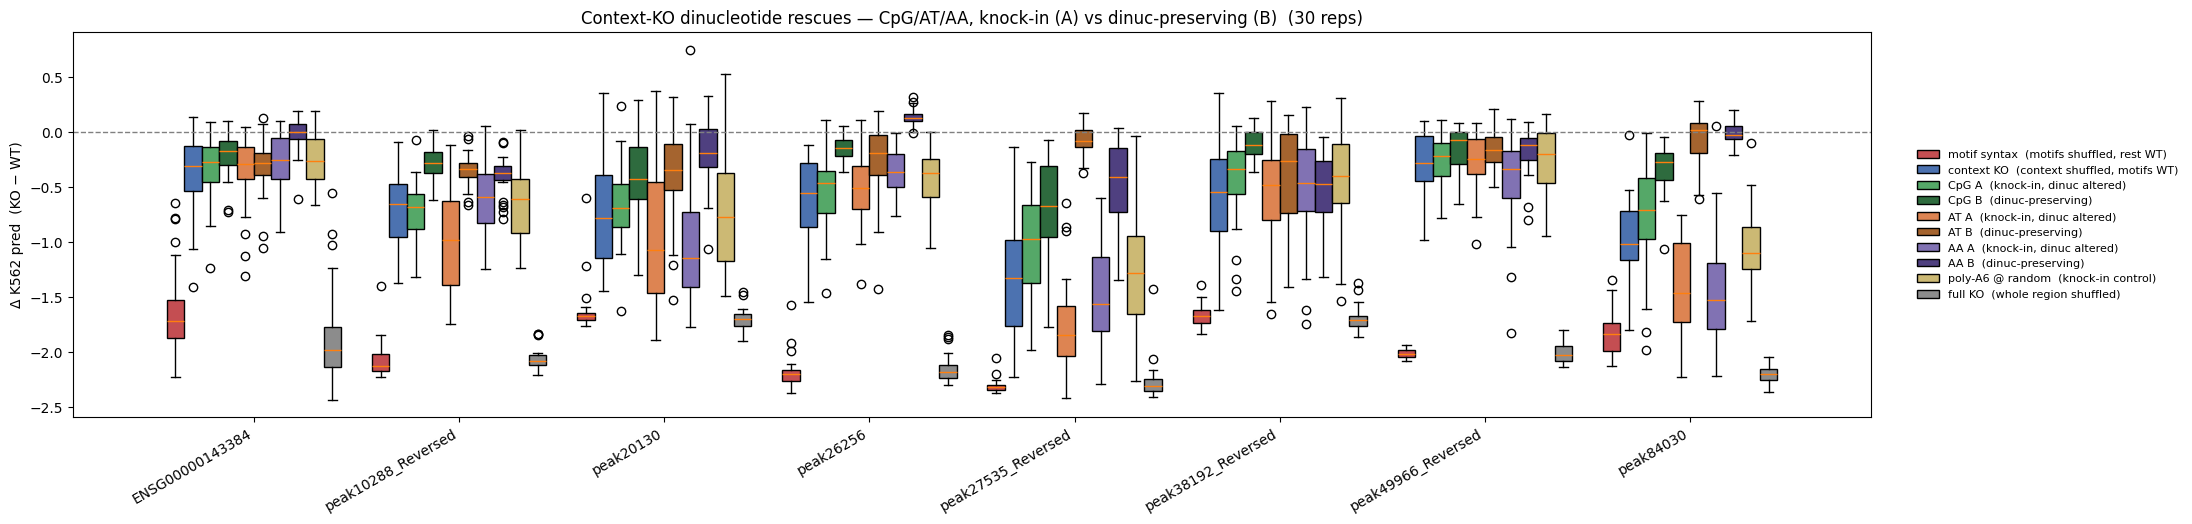

In [22]:
# delta = KO - WT (per rep). Reference boxes (motif / context / full) + per-class rescues:
#   A = knock-in (dinuc positions restored, dinuc content altered)
#   B = dinuc-preserving (dinuc positions restored AND dinuc content kept exact)
w = 0.085
xg = np.arange(len(ko_peaks))
delt = lambda dic: [dic[p] - wt_pred[p] for p in ko_peaks]

# (label, per-seq delta lists, facecolor)
boxes = [('motif syntax  (motifs shuffled, rest WT)',  delt(motifko_pred), '#c44e52'),
         ('context KO  (context shuffled, motifs WT)', delt(ctxko_pred),   '#4c72b0')]
CLASS_COLORS = {'CpG': ('#55a868', '#2e6b3e'), 'AT': ('#dd8452', '#a5642f'), 'AA': ('#8172b3', '#4f4080')}
for c in CATS:
    boxes.append((f'{c} A  (knock-in, dinuc altered)', delt(rescueA[c]), CLASS_COLORS[c][0]))
    boxes.append((f'{c} B  (dinuc-preserving)',        delt(rescueB[c]), CLASS_COLORS[c][1]))
boxes.append(('poly-A6 @ random  (knock-in control)', delt(polyA_pred),  '#ccb974'))
boxes.append(('full KO  (whole region shuffled)',     delt(fullko_pred), '#8c8c8c'))

n = len(boxes)
fig, ax = plt.subplots(figsize=(3.8 * len(ko_peaks) + 2, 5))
handles = []
for k, (lab, data, col) in enumerate(boxes):
    b = ax.boxplot(data, positions=xg + (k - (n - 1) / 2) * w, widths=w, patch_artist=True)
    for box in b['boxes']:
        box.set_facecolor(col)
    handles.append(b['boxes'][0])
ax.axhline(0, color='0.5', lw=1, ls='--')
ax.set_xticks(xg); ax.set_xticklabels(ko_peaks, rotation=30, ha='right')
ax.set_ylabel('Δ K562 pred  (KO − WT)')
ax.set_title(f'Context-KO dinucleotide rescues — CpG/AT/AA, knock-in (A) vs dinuc-preserving (B)  ({N_REP} reps)')
ax.legend(handles, [lab for lab, _, _ in boxes],
          loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=False)
fig.subplots_adjust(right=0.68)

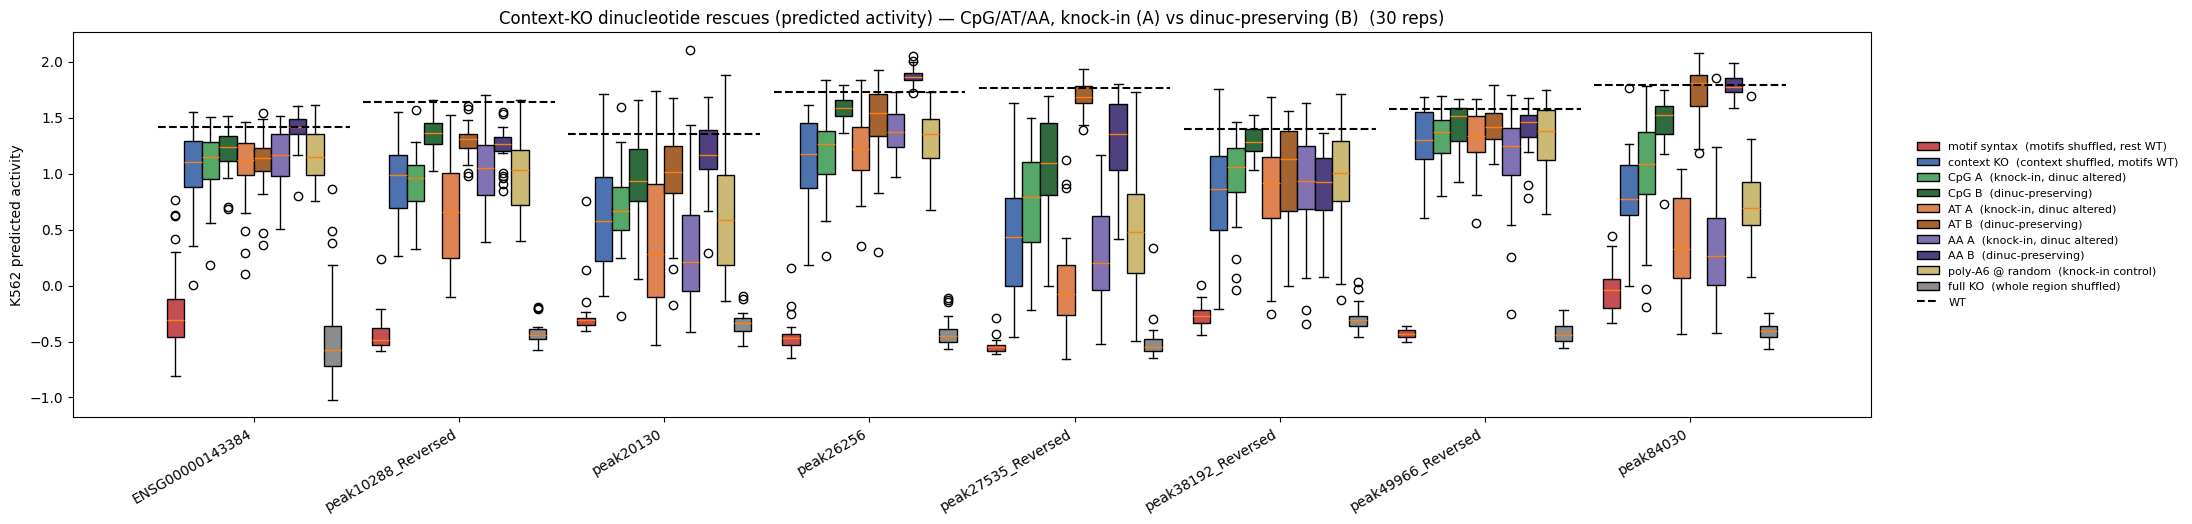

In [23]:
# same layout but y = raw predicted K562 activity (not delta); WT shown as a reference line per seq
w = 0.085
xg = np.arange(len(ko_peaks))
raw = lambda dic: [dic[p] for p in ko_peaks]

boxes = [('motif syntax  (motifs shuffled, rest WT)',  raw(motifko_pred), '#c44e52'),
         ('context KO  (context shuffled, motifs WT)', raw(ctxko_pred),   '#4c72b0')]
CLASS_COLORS = {'CpG': ('#55a868', '#2e6b3e'), 'AT': ('#dd8452', '#a5642f'), 'AA': ('#8172b3', '#4f4080')}
for c in CATS:
    boxes.append((f'{c} A  (knock-in, dinuc altered)', raw(rescueA[c]), CLASS_COLORS[c][0]))
    boxes.append((f'{c} B  (dinuc-preserving)',        raw(rescueB[c]), CLASS_COLORS[c][1]))
boxes.append(('poly-A6 @ random  (knock-in control)', raw(polyA_pred),  '#ccb974'))
boxes.append(('full KO  (whole region shuffled)',     raw(fullko_pred), '#8c8c8c'))

n = len(boxes)
span = (n - 1) / 2 * w + w
fig, ax = plt.subplots(figsize=(3.8 * len(ko_peaks) + 2, 5))
handles = []
for k, (lab, data, col) in enumerate(boxes):
    b = ax.boxplot(data, positions=xg + (k - (n - 1) / 2) * w, widths=w, patch_artist=True)
    for box in b['boxes']:
        box.set_facecolor(col)
    handles.append(b['boxes'][0])
# WT reference (one value per seq)
for j, p in enumerate(ko_peaks):
    ax.hlines(wt_pred[p], xg[j] - span, xg[j] + span, color='k', lw=1.5, ls='--', zorder=5)
wt_handle = ax.hlines([], [], [], color='k', lw=1.5, ls='--')
ax.set_xticks(xg); ax.set_xticklabels(ko_peaks, rotation=30, ha='right')
ax.set_ylabel('K562 predicted activity')
ax.set_title(f'Context-KO dinucleotide rescues (predicted activity) — CpG/AT/AA, knock-in (A) vs dinuc-preserving (B)  ({N_REP} reps)')
ax.legend(handles + [wt_handle], [lab for lab, _, _ in boxes] + ['WT'],
          loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=False)
fig.subplots_adjust(right=0.68)

ENSG00000143384          WT=+1.414  motifKO=-0.196  ctxKO=+1.046  fullKO=-0.425  CpG=+0.269  AT=+1.212  AA=+0.755
peak10288_Reversed       WT=+1.640  motifKO=-0.432  ctxKO=+0.926  fullKO=-0.425  CpG=+1.412  AT=+1.437  AA=+1.199
peak20130                WT=+1.358  motifKO=-0.271  ctxKO=+0.602  fullKO=-0.344  CpG=+1.102  AT=+1.343  AA=+0.884
peak26256                WT=+1.732  motifKO=-0.448  ctxKO=+1.127  fullKO=-0.426  CpG=+1.572  AT=+1.473  AA=+1.524


peak27535_Reversed       WT=+1.765  motifKO=-0.543  ctxKO=+0.458  fullKO=-0.504  CpG=+1.236  AT=+1.524  AA=+1.218
peak38192_Reversed       WT=+1.402  motifKO=-0.267  ctxKO=+0.840  fullKO=-0.299  CpG=+0.987  AT=+1.326  AA=+1.307
peak49966_Reversed       WT=+1.582  motifKO=-0.430  ctxKO=+1.296  fullKO=-0.437  CpG=+1.512  AT=+1.514  AA=+1.492
peak84030                WT=+1.795  motifKO=-0.029  ctxKO=+0.778  fullKO=-0.405  CpG=+0.884  AT=+1.432  AA=+1.331


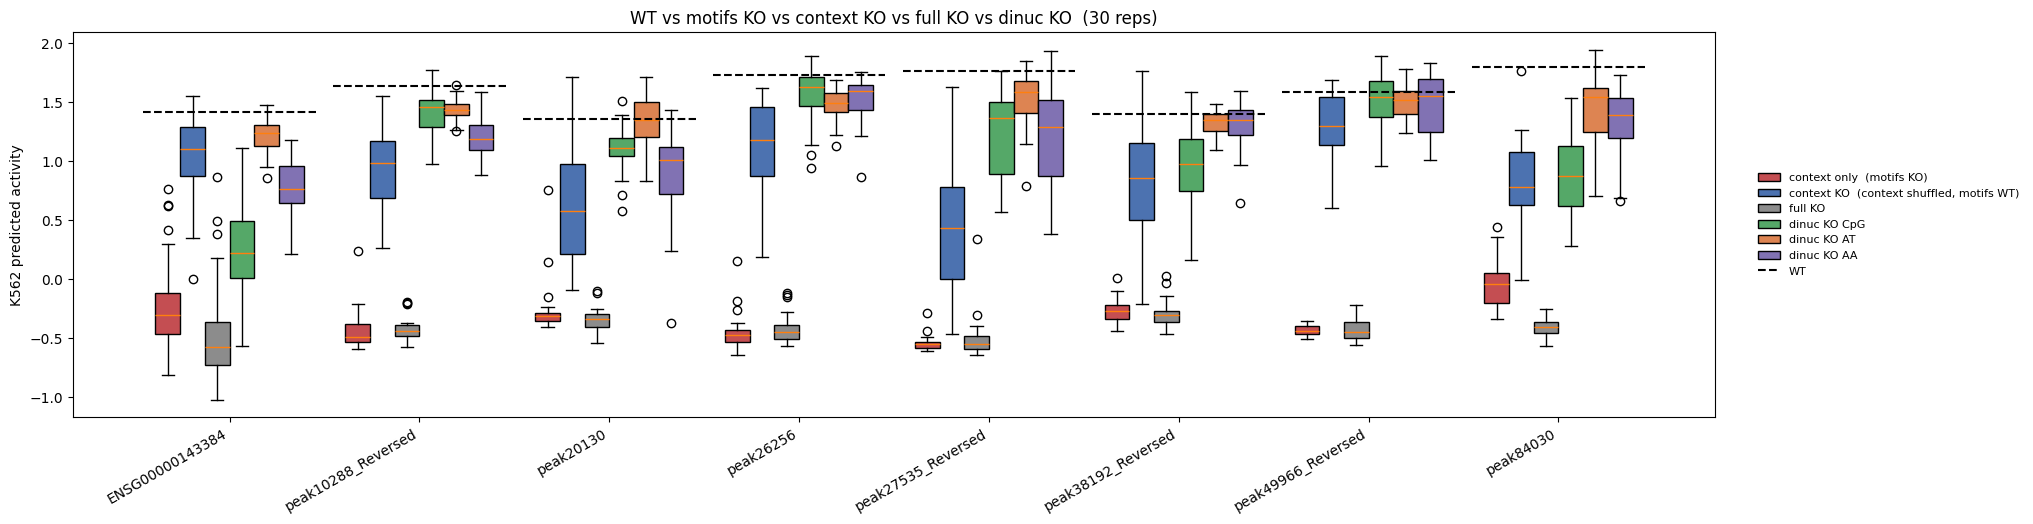

In [24]:
# WT vs context-only (motifs KO) vs context KO vs full KO vs dinuc KO — predicted K562 activity.
# dinuc KO = fully intact WT with the target dinucs shifted off their WT positions:
#   motifs kept WT, mono-nuc content exact (pure base swaps), no target dinuc left at
#   its WT context position. N_REP reps per seq (one per rng draw).
def _motif_mask(motifs):
    m = np.zeros(200, bool)
    for _, r in motifs.iterrows():
        m[r.start:r.end] = True
    return m

def dinuc_ko_seq(vseq, dinucs, mmask, rng):
    s = list(vseq.upper())
    ctx = np.array([i for i in range(200) if not mmask[i]])
    def ctx_target(k):                       # target dinuc fully inside context, start k
        return (0 <= k < 199 and not mmask[k] and not mmask[k + 1]
                and (s[k] + s[k + 1]) in dinucs)
    def makes_target(k):
        return ctx_target(k - 1) or ctx_target(k)
    for _ in range(4000):
        bad = [k for k in range(199) if ctx_target(k)]
        if not bad:
            break
        i = bad[0]; moved = False
        for p in (i + 1, i):                 # relocate either base of the dinuc
            for j in rng.permutation(ctx):
                j = int(j)
                if j in (i, i + 1):
                    continue
                s[p], s[j] = s[j], s[p]
                if not (makes_target(p) or makes_target(j)):
                    moved = True; break
                s[p], s[j] = s[j], s[p]       # revert: swap re-formed a target dinuc
            if moved:
                break
        if not moved:
            break
    return ''.join(s)

# predict the dinuc KO (wt_pred / motifko_pred / ctxko_pred / fullko_pred already computed above)
dinucko_pred = {c: {} for c in CATS}
rng = np.random.default_rng(0)
for peak in ko_peaks:
    wt, vseq, motifs, ADAPTER, _ = _load(peak)
    mmask = _motif_mask(motifs)
    for c, dinucs in CATS.items():
        x = wt.unsqueeze(0).repeat(N_REP, 1, 1).clone()
        for rep in range(N_REP):
            x[rep, :, ADAPTER:ADAPTER + 200] = one_hot_encode(dinuc_ko_seq(vseq, dinucs, mmask, rng)).float()
        dinucko_pred[c][peak] = predict_k562(x)             # (N_REP,)
    print(f'{peak:24s} WT={wt_pred[peak]:+.3f}  motifKO={motifko_pred[peak].mean():+.3f}  '
          f'ctxKO={ctxko_pred[peak].mean():+.3f}  fullKO={fullko_pred[peak].mean():+.3f}  '
          + '  '.join(f'{c}={dinucko_pred[c][peak].mean():+.3f}' for c in CATS))

# boxplot: raw predicted activity, WT reference line per seq (matches the cell above)
w  = 0.13
xg = np.arange(len(ko_peaks))
raw = lambda dic: [dic[p] for p in ko_peaks]
boxes = [('context only  (motifs KO)',                 raw(motifko_pred), '#c44e52'),
         ('context KO  (context shuffled, motifs WT)',  raw(ctxko_pred),   '#4c72b0'),
         ('full KO',                                    raw(fullko_pred),  '#8c8c8c')]
DINUC_COLORS = {'CpG': '#55a868', 'AT': '#dd8452', 'AA': '#8172b3'}
for c in CATS:
    boxes.append((f'dinuc KO {c}', raw(dinucko_pred[c]), DINUC_COLORS[c]))

n = len(boxes)
span = (n - 1) / 2 * w + w
fig, ax = plt.subplots(figsize=(3.2 * len(ko_peaks) + 2, 5))
handles = []
for k, (lab, data, col) in enumerate(boxes):
    b = ax.boxplot(data, positions=xg + (k - (n - 1) / 2) * w, widths=w, patch_artist=True)
    for box in b['boxes']:
        box.set_facecolor(col)
    handles.append(b['boxes'][0])
for j, p in enumerate(ko_peaks):
    ax.hlines(wt_pred[p], xg[j] - span, xg[j] + span, color='k', lw=1.5, ls='--', zorder=5)
wt_handle = ax.hlines([], [], [], color='k', lw=1.5, ls='--')
ax.set_xticks(xg); ax.set_xticklabels(ko_peaks, rotation=30, ha='right')
ax.set_ylabel('K562 predicted activity')
ax.set_title(f'WT vs motifs KO vs context KO vs full KO vs dinuc KO  ({N_REP} reps)')
ax.legend(handles + [wt_handle], [l for l, _, _ in boxes] + ['WT'],
          loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=False)
fig.subplots_adjust(right=0.72)

ENSG00000143384          WT=+1.414  ctxKO=+1.046  fullKO=-0.425  tgtCpG=+1.173  tgtAT=+1.286  tgtAA=+1.176
peak10288_Reversed       WT=+1.640  ctxKO=+0.926  fullKO=-0.425  tgtCpG=+1.347  tgtAT=+1.616  tgtAA=+1.387
peak20130                WT=+1.358  ctxKO=+0.602  fullKO=-0.344  tgtCpG=+1.132  tgtAT=+1.309  tgtAA=+1.236
peak26256                WT=+1.732  ctxKO=+1.127  fullKO=-0.426  tgtCpG=+1.734  tgtAT=+1.658  tgtAA=+1.461
peak27535_Reversed       WT=+1.765  ctxKO=+0.458  fullKO=-0.504  tgtCpG=+1.119  tgtAT=+1.523  tgtAA=+1.416
peak38192_Reversed       WT=+1.402  ctxKO=+0.840  fullKO=-0.299  tgtCpG=+1.291  tgtAT=+1.398  tgtAA=+1.473
peak49966_Reversed       WT=+1.582  ctxKO=+1.296  fullKO=-0.437  tgtCpG=+1.329  tgtAT=+1.623  tgtAA=+1.459
peak84030                WT=+1.795  ctxKO=+0.778  fullKO=-0.405  tgtCpG=+1.046  tgtAT=+1.652  tgtAA=+1.197


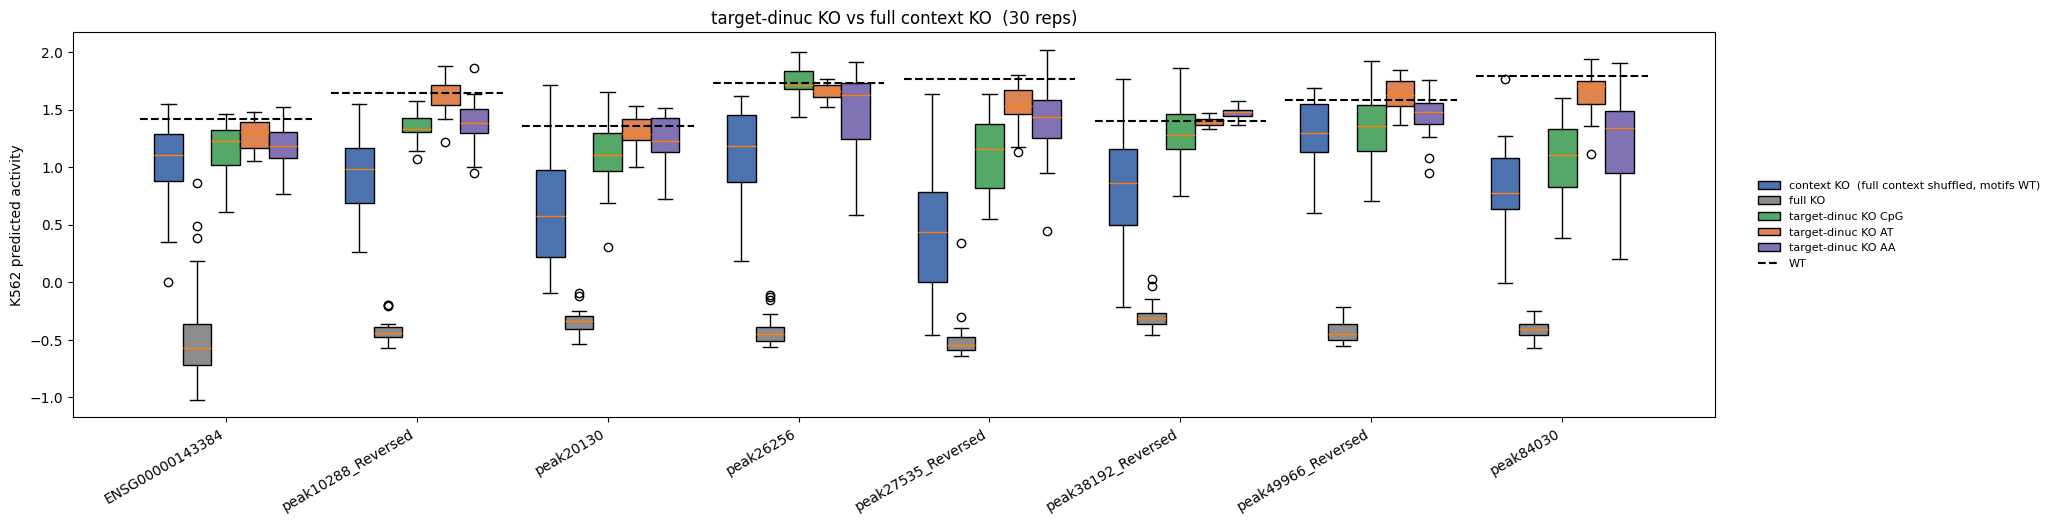

In [25]:
# target-dinuc KO: replace ONLY the target-dinuc context positions with a full dinuc-shuffle
# of the seq at those SAME positions (motifs left WT). No relocation / content-matching — the
# target dinucs are simply overwritten by shuffled bases. Tests whether knocking out just the
# target dinucs recapitulates the full context KO.
tgtko_pred = {c: {} for c in CATS}
for peak in ko_peaks:
    wt, vseq, motifs, ADAPTER, shuf = _load(peak)          # shuf: (N_REP,4,200) full var dinuc-shuffle
    mmask = _motif_mask(motifs)
    for c, dinucs in CATS.items():
        pos = np.zeros(200, bool)                          # target-dinuc positions, both bases in context
        for i in range(199):
            if not mmask[i] and not mmask[i + 1] and vseq[i:i + 2].upper() in dinucs:
                pos[i] = pos[i + 1] = True
        sel = np.where(pos)[0]
        x = wt.unsqueeze(0).repeat(N_REP, 1, 1).clone()
        x[:, :, sel + ADAPTER] = shuf[:, :, sel]           # overwrite target-dinuc positions with the shuffle
        tgtko_pred[c][peak] = predict_k562(x)              # (N_REP,)
    print(f'{peak:24s} WT={wt_pred[peak]:+.3f}  ctxKO={ctxko_pred[peak].mean():+.3f}  '
          f'fullKO={fullko_pred[peak].mean():+.3f}  '
          + '  '.join(f'tgt{c}={tgtko_pred[c][peak].mean():+.3f}' for c in CATS))

# boxplot: raw predicted activity, WT reference line per seq
w  = 0.15
xg = np.arange(len(ko_peaks))
raw = lambda dic: [dic[p] for p in ko_peaks]
boxes = [('context KO  (full context shuffled, motifs WT)', raw(ctxko_pred), '#4c72b0'),
         ('full KO',                                        raw(fullko_pred), '#8c8c8c')]
DINUC_COLORS = {'CpG': '#55a868', 'AT': '#dd8452', 'AA': '#8172b3'}
for c in CATS:
    boxes.append((f'target-dinuc KO {c}', raw(tgtko_pred[c]), DINUC_COLORS[c]))

n = len(boxes)
span = (n - 1) / 2 * w + w
fig, ax = plt.subplots(figsize=(3.2 * len(ko_peaks) + 2, 5))
handles = []
for k, (lab, data, col) in enumerate(boxes):
    b = ax.boxplot(data, positions=xg + (k - (n - 1) / 2) * w, widths=w, patch_artist=True)
    for box in b['boxes']:
        box.set_facecolor(col)
    handles.append(b['boxes'][0])
for j, p in enumerate(ko_peaks):
    ax.hlines(wt_pred[p], xg[j] - span, xg[j] + span, color='k', lw=1.5, ls='--', zorder=5)
wt_handle = ax.hlines([], [], [], color='k', lw=1.5, ls='--')
ax.set_xticks(xg); ax.set_xticklabels(ko_peaks, rotation=30, ha='right')
ax.set_ylabel('K562 predicted activity')
ax.set_title(f'target-dinuc KO vs full context KO  ({N_REP} reps)')
ax.legend(handles + [wt_handle], [l for l, _, _ in boxes] + ['WT'],
          loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=False)
fig.subplots_adjust(right=0.72)